In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
### Configuration ###
BATCH_SIZE    = 16
LEARNING_RATE = 6E-3
NUM_EPOCHS    = 500
FNAME_MODEL   = 'regressor.pt'

In [3]:
fname = "data/IVESPAvn1.0.csv"
df = pd.read_csv(fname)

In [4]:
# Compute mass emission rate in kg/s
df['MER'] = df['TEM']/(df['Duration']*3600)
df['target'] = np.log(df['MER'])
df

,Volcano,Latitude,Longitude,Vent altitude,Year,Duration,TEM,Plume top height,Wind NOAA,Brunt-Väisälä frequency NOAA,Wind shear NOAA,Wind speed ERA,Brunt-Väisälä frequency ERA,Wind shear ERA,MER,target
0,Agung,-8.343,115.508,3142,1963,5.2500,3.740000e+11,13.0,10.082076,0.010783,0.001940,3.571636,0.010003,0.000513,1.978836e+07,16.800604
1,Agung,-8.343,115.508,3142,1963,4.5000,3.540000e+11,13.0,8.186314,0.010612,0.001343,8.762418,0.010028,0.001564,2.185185e+07,16.899796
2,Anatahan,16.350,145.670,0,2003,35.0000,2.930000e+10,8.0,5.437572,0.011969,0.000786,6.436519,0.011967,0.001061,2.325397e+05,12.356816
3,Anatahan,16.350,145.670,0,2003,48.0000,9.250000e+09,2.5,2.798929,0.011524,0.001860,3.230936,0.011852,0.001914,5.353009e+04,10.887999
4,Augustine,59.363,-153.430,1252,2006,0.0697,1.730000e+09,13.5,4.372798,0.015210,0.000612,5.993524,0.015298,0.000760,6.894628e+06,15.746253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Tungurahua,-1.467,-78.442,5023,2006,5.0000,2.490000e+10,16.0,5.855170,0.010954,0.000646,6.192126,0.010114,0.000746,1.383333e+06,14.140007
126,Tungurahua,-1.467,-78.442,5023,2013,1.0000,6.720000e+08,11.4,7.209165,0.010044,0.001788,8.735809,0.010338,0.002128,1.866667e+05,12.137080
127,Tungurahua,-1.467,-78.442,5023,2014,0.4300,5.400000e+09,13.7,5.087269,0.009961,0.000833,5.785914,0.009343,0.001147,3.488372e+06,15.064946
128,Tyatya,44.353,146.252,500,1973,96.0000,2.600000e+11,8.0,13.745128,0.013319,0.003429,16.355454,0.013083,0.003951,7.523148e+05,13.530910


In [5]:
features = ['Vent altitude', 'Plume top height', 'Wind NOAA', 'Brunt-Väisälä frequency NOAA', 'Wind shear NOAA']
#features = ['Vent altitude', 'Plume top height', 'Wind speed ERA', 'Brunt-Väisälä frequency ERA', 'Wind shear ERA']

X = df[features].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
X.shape, y.shape

((130, 5), (130,))

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape

((104, 5), (26, 5))

In [7]:
# Create a Transform Class for Normalization
class Normalize:
    def __init__(self, mean, std):
        self.mean = torch.from_numpy(mean).float()
        self.std  = torch.from_numpy(std).float()
        self.std[self.std == 0] = 1.0  # Avoid division by zero

    def __call__(self, x):
        return (x - self.mean) / self.std

    def invert(self, x):
        return (x * self.std + self.mean)

In [8]:
class RegressionDataset(Dataset):
    def __init__(self, X, y, transform = None):
        """
        X: NumPy array of shape (n_samples, n_features)
        y: NumPy array of shape (n_samples, 1)
        """
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

In [9]:
# Compute normalization stats from training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Define transform
transform = Normalize(mean, std)

# Datasets
train_dataset = RegressionDataset(X_train, y_train, transform=transform)
val_dataset   = RegressionDataset(X_val, y_val, transform=transform)

In [10]:
# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# Define the model
class SimpleRegressor(nn.Module):
    def __init__(self):
        super(SimpleRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 32),       # Input layer → hidden
            #nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),      # Hidden layer
            #nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),       # Output layer
            nn.Softplus()           # Ensures output is positive
        )

    def forward(self, x):
        return self.model(x)

In [12]:
# Instantiate model
model = SimpleRegressor()
summary(model, (5,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]             192
              ReLU-2                   [-1, 32]               0
           Dropout-3                   [-1, 32]               0
            Linear-4                   [-1, 16]             528
              ReLU-5                   [-1, 16]               0
           Dropout-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]               0
Total params: 737
Trainable params: 737
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [13]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        optimizer.zero_grad()
        prediction = model(X)
        loss = criterion(prediction,y)
        loss.backward()
        optimizer.step()
        
        # Get current batch size
        current_batch_size = X.size(0)
        total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

In [14]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            prediction = model(X)
            loss = criterion(prediction,y)

            # Get current batch size
            current_batch_size = X.size(0)
            total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

## Training loop

In [15]:
# Loss and optimizer
model = SimpleRegressor()
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [16]:
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    # Store current losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch%100 == 0 or epoch == NUM_EPOCHS-1:
        print(f"Epoch {epoch+1:02d} -> Train loss {train_loss:.4f} | Test loss: {val_loss:.4f}")

Epoch 01 -> Train loss 176.8521 | Test loss: 162.2862
Epoch 101 -> Train loss 7.4673 | Test loss: 4.2007
Epoch 201 -> Train loss 4.6276 | Test loss: 3.4794
Epoch 301 -> Train loss 5.9323 | Test loss: 2.5628
Epoch 401 -> Train loss 4.6528 | Test loss: 2.7850
Epoch 500 -> Train loss 3.7566 | Test loss: 2.7132


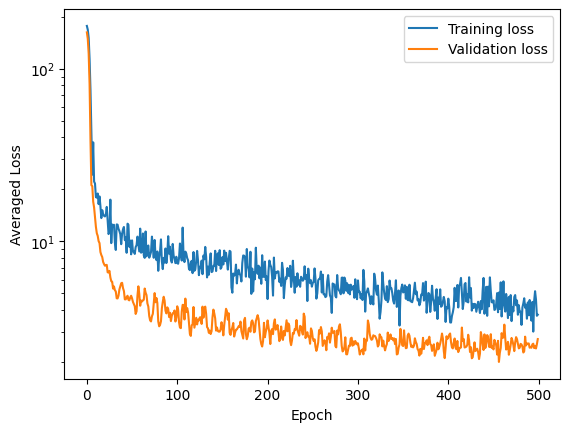

In [17]:
fig, ax = plt.subplots()

ax.plot(train_losses, label = 'Training loss')
ax.plot(val_losses, label = 'Validation loss')
ax.set(xlabel= "Epoch", ylabel= "Averaged Loss", yscale="log")
ax.legend()
#plt.set_yscale('log')

<Axes: >

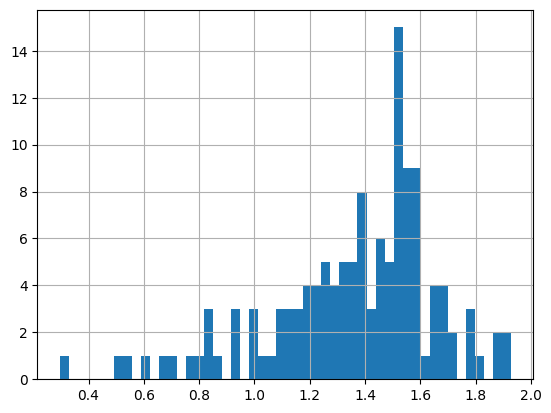

In [18]:
d = df['MER']
dd = 0.1*np.log(d)
dd.hist(bins=50)

In [19]:
model.eval()

#ax = df.plot.scatter(x='Plume top height', y='MER', logy=True)

#h = np.linspace(0,40,100)
#mastin = 140.8 * h**4.15
#ax.plot(h, mastin, 'g-')

heights = []
emission_raters = []
targets = []
with torch.no_grad():
    for X, y in val_loader:
        prediction = model(X)
        xx = transform.invert(X)
        heights.append(xx[:,1])
        emission_raters.append(prediction.squeeze())
        targets.append(y.squeeze())
h  = torch.cat(heights)
yp = torch.cat(emission_raters)
y  = torch.cat(targets)

In [20]:
criterion(yp,y)

tensor(2.7132)

In [21]:
ym = 140.8 * h**4.15
ym = torch.log(ym)
criterion(ym,y)

tensor(10.1947)

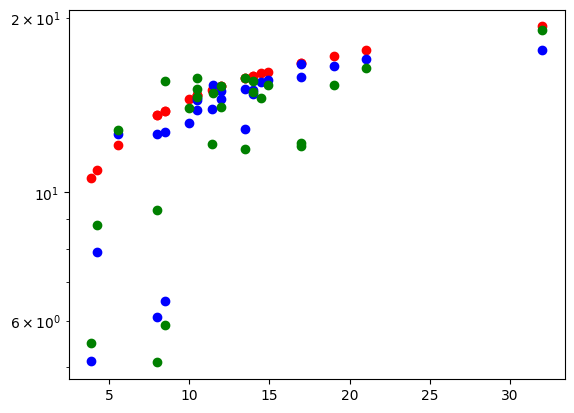

In [22]:
fig, ax = plt.subplots()

ax.plot(h,ym, 'ro')
ax.plot(h,yp, 'bo')
ax.plot(h,y, 'go')
ax.set_yscale('log')


In [ ]:
fig, ax = plt.subplots()

ax.plot(y,ym, 'ro')
ax.plot(y,yp, 'bo', mfc="none")
ax.plot([5,20],[5,20],'k-')
#ax.set_yscale('log')

<Axes: xlabel='Brunt-Väisälä frequency NOAA', ylabel='target'>

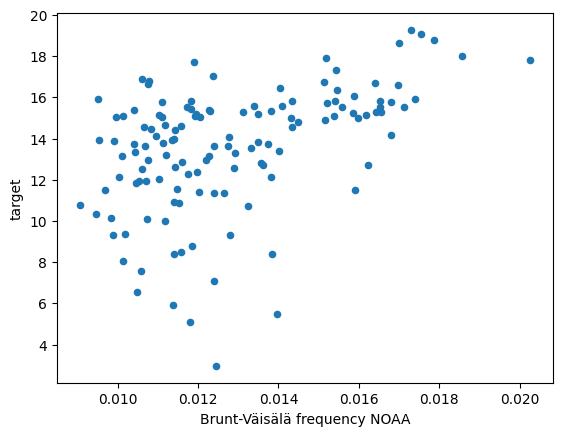

In [28]:
#df.plot.scatter(x='Wind NOAA', y='target')
#df.plot.scatter(x='Wind shear NOAA', y='target')
df.plot.scatter(x='Brunt-Väisälä frequency NOAA', y='target')
